# Comparision on query Level

In [2]:
import sys
import re
import matplotlib.pyplot as plt
import statistics
import numpy as np
sys.path.append("../..")
from utils.processing import json_file_access, evaluate, evaluate_mrr
from beir.retrieval.evaluation import EvaluateRetrieval
from beir.datasets.data_loader import GenericDataLoader
from itertools import combinations
from collections import defaultdict
import pandas as pd


c:\Users\marvi\.conda\envs\masterthesis\Lib\site-packages\beir\datasets\data_loader.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
evaluator = EvaluateRetrieval()

corpus, queries, qrels = GenericDataLoader(data_folder="../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

results_rq1 = json_file_access("../../05_results/rq1/results_rq1.json","r")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [28]:
colors = ['deepskyblue', 'darkorange', 'darkgreen', 'navy']

def differ_query_types(query):
    if query.startswith("INEX_LD"):
        return "INEX-LD"
    elif query.startswith("QALD2"):
        return "QALD-2"
    elif query.startswith("SemSearch_ES"):
        return "SemSearch ES"
    else:
        return "ListSearch"
    
query_types = {}
for key in queries.keys():
    query_type = differ_query_types(key)
    if query_type in query_types.keys() and isinstance(query_types[query_type], list):
        query_types[query_type].append(key)
    else:
        query_types[query_type] = [key]

In [ ]:
# Tabelle 7
evaluate_mrr(results_rq1,[10], evaluator, qrels)

,search_type,MRR@10
0,boolean,0.48998
1,bm25,0.60792
2,vector,0.64851
3,hybrid,0.71285


## Abbildungen 21 - 24

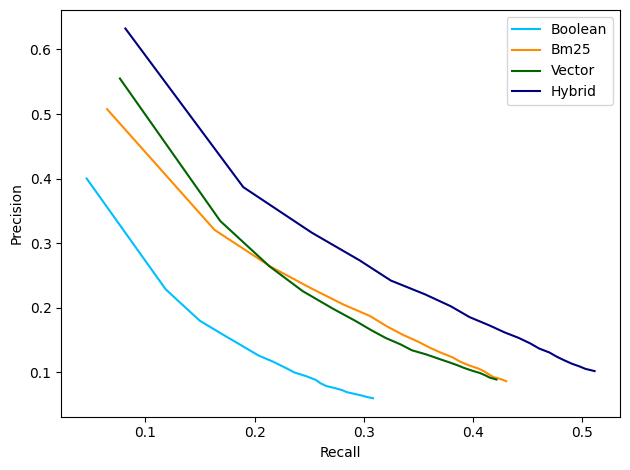

In [83]:
# Abbildung 23 links
k_values = [i for i in range(1,100,5)]

plt.figure()
for ir_type, col  in zip(results_rq1.keys(), colors):
    metrics = evaluator.evaluate(qrels, results_rq1[ir_type], k_values=k_values)
    precision_vals = []
    recall_vals = []

    num_cuts = len(k_values)
    for k in k_values:
        p = metrics[3].get(f"P@{k}", 0)       # Precision@k
        r = metrics[2].get(f"Recall@{k}", 0)  # Recall@k
        precision_vals.append(p)
        recall_vals.append(r)

    # Sort them by recall to ensure a proper curve
    combined = list(zip(recall_vals, precision_vals))
    combined.sort(key=lambda x: x[0])
    recall_vals, precision_vals = zip(*combined)

    # Plot the macro-averaged curve
    plt.plot(recall_vals, precision_vals,color=col, label=ir_type.title())
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
plt.tight_layout()
plt.savefig("Abbildung_23_links.svg")
plt.show()

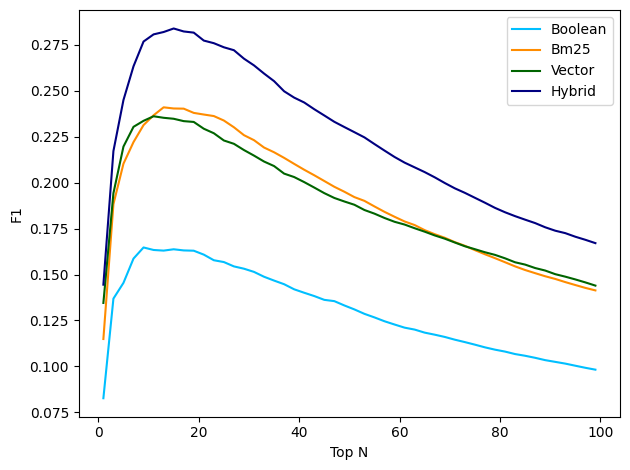

In [84]:
# Abbildung 23 rechts
k = [i for i in range(1,101,2)]
eval_df = evaluate(results_rq1,k, evaluator, qrels)
eval_r =  eval_df[[col for col in eval_df.columns if "Recall" in col]]
eval_p = eval_df[[col for col in eval_df.columns if re.search("^P@\d{1,2}", col)]]
eval_r.columns = eval_p.columns
eval_f1 = 2 *(eval_p * eval_r)/ (eval_r+eval_p)
eval_f1["search_type"] = eval_df["search_type"]

for i ,ir_type in enumerate(eval_df.search_type.to_list()):
    plt.plot(k, eval_f1[eval_f1["search_type"]==ir_type][["P@"+str(num) for num in k]].iloc[0], label=ir_type.title(),  color=colors[i])
plt.xlabel("Top N")
plt.ylabel("F1")
plt.tight_layout()
plt.legend()
plt.savefig("Abbildung_23_rechts.svg")
plt.show()

In [85]:
k = [i for i in range(10,101,10)]
eval_df = evaluate(results_rq1,k, evaluator, qrels)

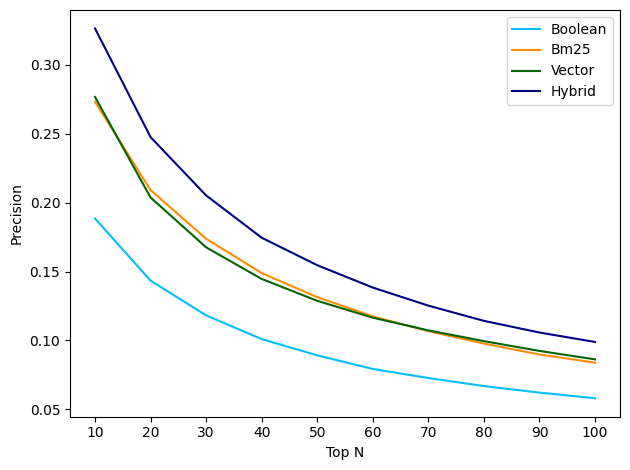

In [86]:
# Abbildung 21 links
x = [str(i) for i in range(10,101,10)]
for i ,ir_type in enumerate(eval_df.search_type.to_list()):
    plt.plot(x, eval_df[eval_df["search_type"]==ir_type][["P@"+str(num) for num in range(10, 101, 10)]].iloc[0], label=ir_type.title(),  color=colors[i])
plt.xlabel("Top N")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("Abbildung_21_links.svg")
plt.show()

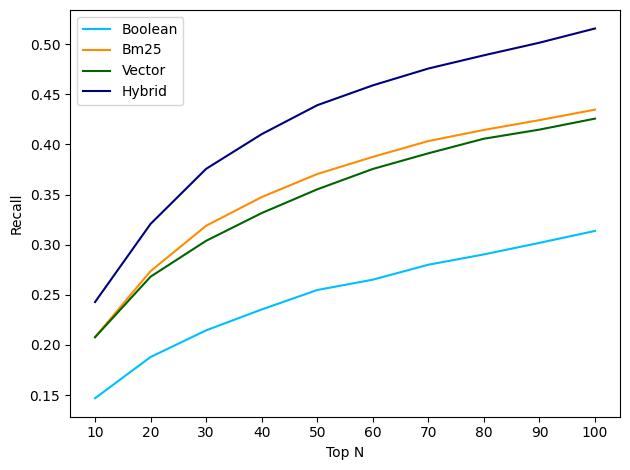

In [87]:
# Abbildung 21 rechts
x = [str(i) for i in range(10,101,10)]
for i ,ir_type in enumerate(eval_df.search_type.to_list()):
    plt.plot(x, eval_df[eval_df["search_type"]==ir_type][["Recall@"+str(num) for num in range(10, 101, 10)]].iloc[0], label=ir_type.title(),  color=colors[i])
plt.xlabel("Top N")
plt.ylabel("Recall")
plt.tight_layout()
plt.legend()
plt.savefig("Abbildung_21_rechts.svg")
plt.show()

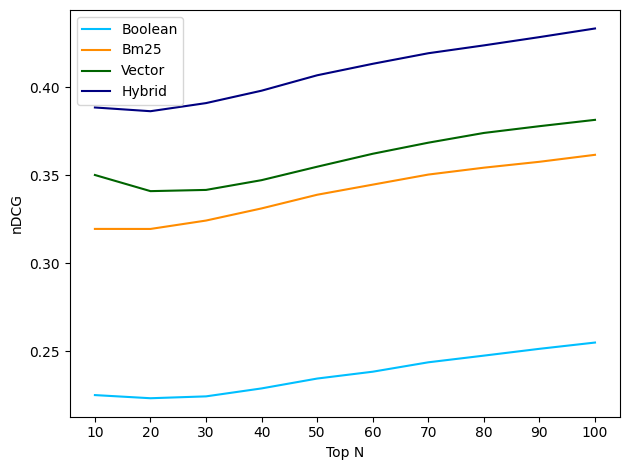

In [88]:
# Abbildung 22 links
x = [str(i) for i in range(10,101,10)]
for i ,ir_type in enumerate(eval_df.search_type.to_list()):
    plt.plot(x, eval_df[eval_df["search_type"]==ir_type][["NDCG@"+str(num) for num in range(10, 101, 10)]].iloc[0], label=ir_type.title(),  color=colors[i])
plt.xlabel("Top N")
plt.ylabel("nDCG")
plt.legend()
plt.tight_layout()
plt.savefig("Abbildung_22_links.svg")
plt.show()

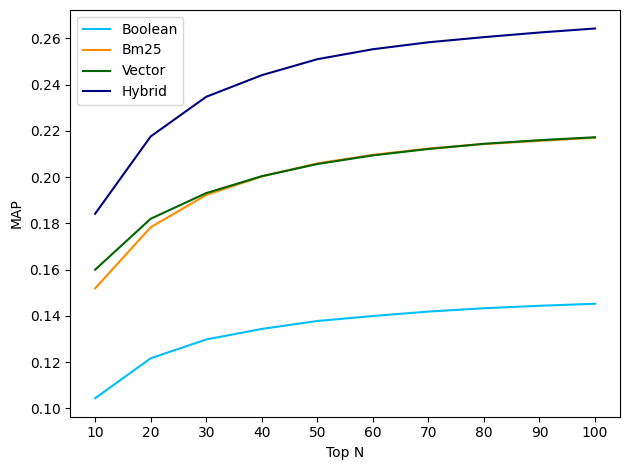

In [89]:
#Abbildung 22 rechts
x = [str(i) for i in range(10,101,10)]
for i ,ir_type in enumerate(eval_df.search_type.to_list()):
    plt.plot(x, eval_df[eval_df["search_type"]==ir_type][["MAP@"+str(num) for num in range(10, 101, 10)]].iloc[0], label=ir_type.title(),  color=colors[i])
plt.xlabel("Top N")
plt.ylabel("MAP")
plt.legend()
plt.tight_layout()
plt.savefig("Abbildung_22_rechts.svg")
plt.show()

In [30]:
res_all = {search_type: {} for search_type in results_rq1.keys()}

for search_type in results_rq1.keys():
    res_in_category = {query_type: {} for query_type in query_types.keys()}
    for query_type in query_types.keys():
        for query in query_types[query_type]:
            res_in_category[query_type][query] = results_rq1[search_type][query]
    res_all[search_type] = res_in_category

In [36]:
evaluator = EvaluateRetrieval()
evaluation_dict = {}
order_list = ["INEX-LD", "QALD-2","SemSearch ES","ListSearch"]
for key in res_all.keys():
    evaluation_dict[key] = evaluate(res_all[key], [10,100], evaluator, qrels)
    evaluation_dict[key] = evaluation_dict[key].set_index('search_type').reindex(order_list).reset_index()

In [90]:
def plot_radar(dfs, order, category_col, value_col, fig_name):
    """
    Parameters
    ----------
    dfs : list of pd.DataFrame
        A list of DataFrames. Each must contain a column for categories (labels)
        and another column for values.
    category_col : str
        Name of the column that contains category names.
    value_col : str
        Name of the column that contains numerical values.
    """
    categories = dfs[0][category_col].tolist()
    N = len(categories)

    # Create angle values for a full circle
    # Note that the first value is repeated at the end to close the polygon
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    # --------------------------------------------
    # 2. Create Radar Figure
    # --------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.spines["polar"].set_visible(False)

    # Set polar plot background details
    ax.set_theta_offset(np.pi / 2)      # Rotate the start so categories begin at the top
    ax.set_theta_direction(-1)         # Clockwise
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, categories)  # Category labels

    # --------------------------------------------
    # 3. Plot Each DataFrame
    # --------------------------------------------
    # We'll choose colors here, but you can customize them
    colors = ['deepskyblue', 'darkorange', 'darkgreen', 'navy']  # Enough for 4 DataFrames
    for i, (df, ir_type) in enumerate(zip(dfs,order)):
        # Retrieve the numerical values and repeat the first to close the polygon
        values = df[value_col].values
        values = np.concatenate((values, [values[0]]))
        ax.plot(angles, values, color=colors[i], linewidth=2, label=ir_type.title())

    # --------------------------------------------
    # 4. Add Legend and Labels
    # --------------------------------------------
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # Show or save the figure
    plt.tight_layout()
    plt.savefig(f"{fig_name}.svg")
    plt.show()

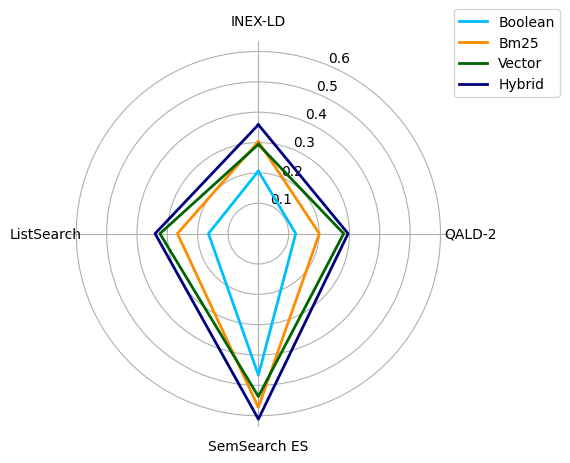

In [91]:
# Abbildung 24 links
category_col = "search_type"
value_col = "NDCG@10"
order = ["boolean","bm25","vector","hybrid"]
dfs = [evaluation_dict[ir_type] for ir_type in order]
plot_radar(dfs, order, category_col, value_col, "Abbildung_24_links")

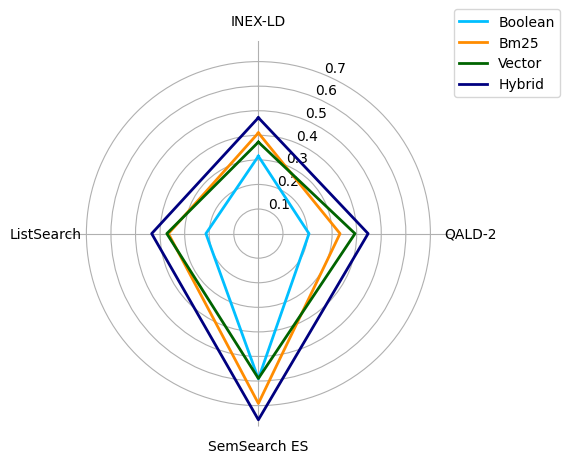

In [92]:
# Abbildung 24 rechts
value_col = "Recall@100"
plot_radar(dfs, order, category_col, value_col, "Abbildung_24_rechts")

In [39]:
def calc_percentage_of_relevant_docs(res_ir: dict, k: int, relevance_level: int):
    res_relevant = {ir_type: [] for ir_type in res_ir.keys()}
    for ir_type, values in res_ir.items():
        
        for query, results in values.items():
                for i, result in enumerate(results.keys()):
                    if i < k:
                        if result in qrels[query].keys():
                            if qrels[query][result] == relevance_level:
                                res_relevant[ir_type].append(1)
                            else:
                                res_relevant[ir_type].append(0)
                        else:
                            res_relevant[ir_type].append(0)

    for ir_type in res_relevant.keys():
        res_relevant[ir_type] = statistics.mean(res_relevant[ir_type])
    return res_relevant

In [ ]:
# Tabelle 6
# Top 10 very relevant
print("Top 10 very relevant:", calc_percentage_of_relevant_docs(results_rq1, 10, 2))
# Top 100 very relevant
print("Top 100 very relevant:", calc_percentage_of_relevant_docs(results_rq1, 100, 2))
# Top 10 relevant
print("Top 10 relevant:", calc_percentage_of_relevant_docs(results_rq1, 10, 1))
# Top 100 relevant
print("Top 100 relevant:", calc_percentage_of_relevant_docs(results_rq1, 100, 1))

Top 10 very relevant: {'boolean': 0.06486351114450288, 'bm25': 0.08635794743429287, 'vector': 0.1165, 'hybrid': 0.12075}
Top 100 very relevant: {'boolean': 0.01651504899380999, 'bm25': 0.02626237313619847, 'vector': 0.0317, 'hybrid': 0.03315}
Top 10 relevant: {'boolean': 0.13398447282744805, 'bm25': 0.18773466833541927, 'vector': 0.16025, 'hybrid': 0.20625}
Top 100 relevant: {'boolean': 0.041625942911560534, 'bm25': 0.057762185189825836, 'vector': 0.054525, 'hybrid': 0.065725}


In [69]:
def calc_intersection_and_union(results):
    # Initialisierung der Ergebnisse
    intersection_counts = defaultdict(dict)
    union_counts = defaultdict(dict)

    # Methoden- und Query-Information extrahieren
    methods = results.keys()
    queries = next(iter(results.values())).keys()

    # Vergleich aller Methodenpaare
    for query in queries:
        for method1, method2 in combinations(methods, 2):
            # Dokumenten-IDs extrahieren
            docs1 = results[method1].get(query, {})
            docs2 = results[method2].get(query, {})
            
            # Schnitt- und Vereinigungsmengen berechnen
            intersection_docs = set(docs1.keys()) & set(docs2.keys())
            union_docs = set(docs1.keys()) | set(docs2.keys())
            
            intersection_counts[query][f"{method1}_{method2}"] = len(intersection_docs)
            union_counts[query][f"{method1}_{method2}"] = len(union_docs)
    return intersection_counts, union_counts

def calc_summary_rates(intersection_counts, union_counts):
    # Aggregation über alle Queries
    summary = {}
    for query in intersection_counts:
        for pair in intersection_counts[query]:
            if pair not in summary:
                summary[pair] = {"intersection": 0, "union": 0}
            summary[pair]["intersection"] += intersection_counts[query][pair]
            summary[pair]["union"] += union_counts[query][pair]

    # Durchschnittliche Übereinstimmungsraten berechnen
    summary_rates = {pair: data["intersection"] / data["union"] if data["union"] > 0 else 0
                    for pair, data in summary.items()}
    return summary_rates

In [82]:
# Function to take the first 10 items
def take_first_n_items(d, n=10):
    return {k: dict(list(v.items())[:n]) for k, v in d.items()}

results_rq1_10 = {
    "boolean": take_first_n_items(results_rq1["boolean"]),
    "bm25": take_first_n_items(results_rq1["bm25"]),
    "vector": take_first_n_items(results_rq1["vector"]),
    "hybrid": take_first_n_items(results_rq1["hybrid"])
}
intersection_counts_10, union_counts_10 = calc_intersection_and_union(results_rq1_10)
summary_rates_10 = calc_summary_rates(intersection_counts_10, union_counts_10)
intersection_counts_100, union_counts_100 = calc_intersection_and_union(results_rq1)
summary_rates_100 = calc_summary_rates(intersection_counts_100, union_counts_100)

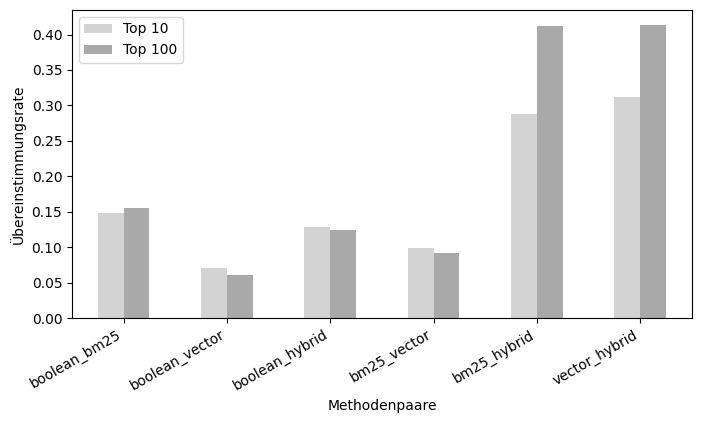

In [ ]:
# Abbildung 25
x = list(summary_rates_10.keys())
y = list(summary_rates_10.values())
z = list(summary_rates_100.values())

# using the existing lists from the OP, create the dataframe
df = pd.DataFrame(data={'Top 10': y, 'Top 100': z}, index=x)

# plot bars or kind='barh' for horizontal bars; adjust figsize accordingly
ax = df.plot(kind='bar', rot=0, xlabel='Methodenpaare', ylabel='Übereinstimmungsrate', figsize=(8, 4), color=["lightgrey", "darkgrey"])
    
plt.xticks(rotation=30, ha="right")

# move the legend out of the plot
ax.legend();
plt.savefig("Abbildung_25.svg", bbox_inches='tight', dpi=300)

In [22]:
# Anhang A-3
def calc_number_of_relevant_docs_in_region(res_ir: dict, lower_bound: int, upper_bound: int, relevance_level: int):
    resi = {}
    res_relevant = defaultdict(dict)
    for ir_type, values in res_ir.items():
        for query, results in values.items():
            res_relevant[ir_type][query] = 0.0
            for i, result in enumerate(results.keys()):
                if i >= lower_bound and i < upper_bound:
                    if result in qrels[query].keys():
                        if qrels[query][result] == relevance_level:
                            res_relevant[ir_type][query] += 1.0
    for ir_type in res_relevant.keys():
        sum = []
        for query in res_relevant[ir_type].keys():
            sum.append(res_relevant[ir_type][query])
        resi[ir_type] = statistics.mean(sum)
    return resi

# Between 10 and 30:
print("Between 10 and 30 relevant:",calc_number_of_relevant_docs_in_region(results_rq1, 10, 30, 1))
print("Between 10 and 30 very relevant:",calc_number_of_relevant_docs_in_region(results_rq1, 10, 30, 2))

Between 10 and 30 relevant: {'boolean': 1.2525, 'bm25': 1.76, 'vector': 1.495, 'hybrid': 1.9875}
Between 10 and 30 very relevant: {'boolean': 0.435, 'bm25': 0.7175, 'vector': 0.765, 'hybrid': 0.905}
